# Simulation study: Brown-Resnick benchmark for seasonal extremal dependence

Goal: test whether the pairwise F-madogram, extremal coefficient $\theta$, and
finite-level $\chi_u$ estimators recover known differences in spatial extremal
dependence in finite samples comparable to the empirical KNMI panel.

Two regimes:
- **Null**: winter and summer share the same Brown-Resnick variogram.
- **Alternative**: winter has a larger range $\rho_W$ than summer $\rho_S$, so
  $\theta_W(h) < \theta_S(h)$ at all relevant distances.

The notebook uses the modules in `python_project/src/`:
- `spatial_utils.py` - station metadata, haversine distance, pair table.
- `dependence_estimators.py` - rank transform, F-madogram, $\theta$, $\chi_u$.
- `br_simulation.py` - theoretical $\theta(h)$ and approximate Brown-Resnick fields.

A full CLI version of the same workflow lives in `scripts/03_run_simulation.py`.

## 1. Setup

In [1]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make src/ importable. Notebooks live in python_project/notebooks/.
HERE = Path.cwd()
SRC_DIR = (HERE.parent / "src") if HERE.name == "notebooks" else (HERE / "python_project" / "src")
assert SRC_DIR.exists(), f"src dir not found: {SRC_DIR}"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
from spatial_utils import (
    DEFAULT_PANEL_STATION_IDS,
    build_pair_table,
    load_station_metadata,
    pairwise_distance_matrix,
    select_panel,
)
from dependence_estimators import (
    chi_u_pairwise,
    empirical_uniform_ranks,
    estimate_all_pairs,
    fmadogram_pairwise,
    theta_from_fmadogram,
)
from br_simulation import (
    br_theta,
    br_variogram,
    make_default_scenarios,
    simulate_brown_resnick_field,
)

config.ensure_output_dirs()
print("src directory:", SRC_DIR)

src directory: c:\Users\floris\Desktop\MSC\thesis_msc\python_project\src


## 2. Notebook parameters

Quick-run defaults so the notebook executes in a few seconds. Bump `N_REP`
and `YEARS` for a publication-quality Monte Carlo.

In [2]:
N_REP = 20  # Monte Carlo replications
YEARS = 50  # years of seasonal block maxima
DAYS_PER_SEASON = 90  # observations per replicate per season
N_OBS_PER_SEASON = YEARS * DAYS_PER_SEASON

ALPHA = 1.0
RHO_NULL = 120.0
RHO_WINTER_ALT = 180.0
RHO_SUMMER_ALT = 60.0

N_FACTORS = 50  # truncation of the Poisson spectral representation
U_GRID = (0.90, 0.95, 0.98)
DIST_BIN_EDGES = (0.0, 50.0, 100.0, 150.0, 200.0, 1e4)
SEED = config.RANDOM_SEED

print(f"N_REP={N_REP}, N_OBS_PER_SEASON={N_OBS_PER_SEASON}, N_FACTORS={N_FACTORS}")

N_REP=20, N_OBS_PER_SEASON=4500, N_FACTORS=50


## 3. Station panel and pairwise distances

The default panel is the 25-station 1991-2025 DJF balanced list (audit threshold
0.80). Coordinates come from `data/station_metadata.csv`; distances are
haversine in km.

In [3]:
metadata = load_station_metadata()
panel = select_panel(DEFAULT_PANEL_STATION_IDS, metadata=metadata)
pair_table = build_pair_table(panel)
D = pairwise_distance_matrix(panel)

print(f"Panel: {panel.n_stations} stations, {len(pair_table)} unordered pairs.")
print(f"Distance range: {pair_table['dist_km'].min():.1f} - {pair_table['dist_km'].max():.1f} km.")
pair_table.head()

Panel: 25 stations, 300 unordered pairs.
Distance range: 13.3 - 310.3 km.


,i,j,station_i,station_j,name_i,name_j,dist_km
0,13,14,06312,06316,OOSTERSCHELDE WP,OOSTERSCHELDE 4,13.297090
1,13,15,06312,06320,OOSTERSCHELDE WP,LICHTEILAND GOEREE,17.999575
2,18,20,06348,06356,CABAUW TOWER AWS,HERWIJNEN AWS,19.496500
3,16,17,06330,06344,HOEK VAN HOLLAND AWS,ROTTERDAM THE HAGUE AP,22.531406
4,3,18,06260,06348,DE BILT AWS,CABAUW TOWER AWS,22.575523


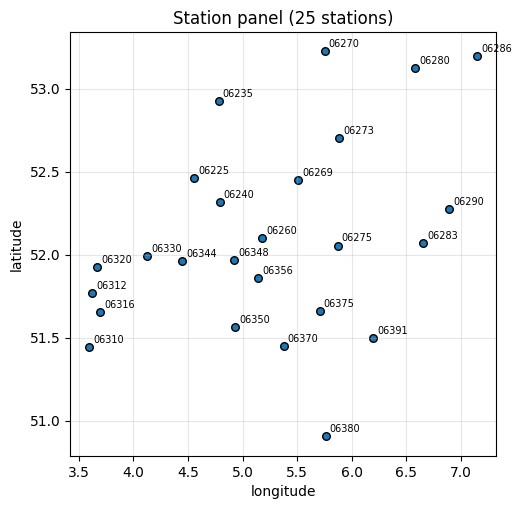

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(panel.lon, panel.lat, s=30, color="tab:blue", edgecolor="k")
for sid, lon, lat in zip(panel.ids, panel.lon, panel.lat):
    ax.annotate(sid, (lon, lat), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title(f"Station panel ({panel.n_stations} stations)")
ax.grid(alpha=0.3)
plt.show()

## 4. Theoretical $\theta(h)$ under null and alternative

$$\gamma(h) = (h/\rho)^\alpha,\qquad \theta(h) = 2\,\Phi\!\left(\tfrac{1}{2}\sqrt{\gamma(h)}\right).$$

       null:  winter rho=120.0, summer rho=120.0
alternative:  winter rho=180.0, summer rho= 60.0


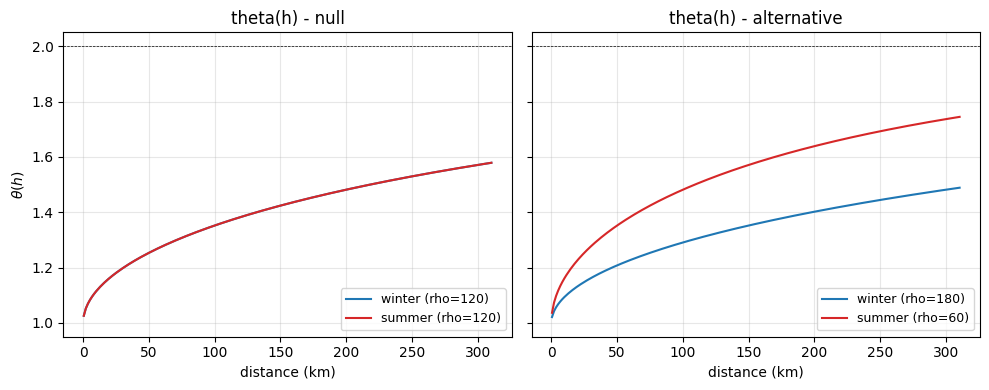

In [5]:
scenarios = make_default_scenarios(
    alpha=ALPHA,
    rho_null=RHO_NULL,
    rho_winter_alt=RHO_WINTER_ALT,
    rho_summer_alt=RHO_SUMMER_ALT,
)
for k, s in scenarios.items():
    print(f"{k:>11}:  winter rho={s.winter.rho:>5}, summer rho={s.summer.rho:>5}")

h_grid = np.linspace(0.5, pair_table["dist_km"].max(), 200)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (k, s) in zip(axes, scenarios.items()):
    for sname, regime, c in (("winter", s.winter, "tab:blue"), ("summer", s.summer, "tab:red")):
        ax.plot(h_grid, br_theta(h_grid, regime.rho, ALPHA), color=c, label=f"{sname} (rho={regime.rho:g})")
    ax.axhline(2.0, color="k", lw=0.5, ls="--")
    ax.set_title(f"theta(h) - {k}")
    ax.set_xlabel("distance (km)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
axes[0].set_ylabel(r"$\theta(h)$")
axes[0].set_ylim(0.95, 2.05)
fig.tight_layout()
plt.show()

## 5. Single-field demo: simulate, rank-transform, estimate

One winter realisation under the alternative regime, to sanity-check the
estimators against the theoretical curve before launching the full Monte
Carlo.

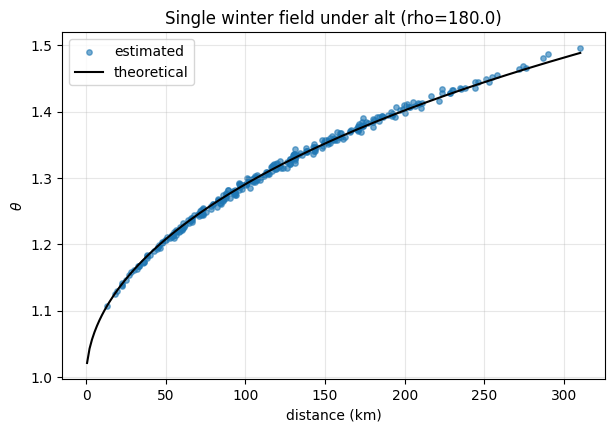

In [6]:
rng = np.random.default_rng(SEED)
X_demo = simulate_brown_resnick_field(
    panel,
    rho=RHO_WINTER_ALT,
    alpha=ALPHA,
    n_obs=N_OBS_PER_SEASON,
    n_factors=N_FACTORS,
    rng=rng,
)
U_demo = empirical_uniform_ranks(X_demo)
nu_demo = fmadogram_pairwise(U_demo)
theta_demo = theta_from_fmadogram(nu_demo)

i_arr = pair_table["i"].to_numpy()
j_arr = pair_table["j"].to_numpy()
demo_pairs = pair_table.copy()
demo_pairs["theta_hat"] = theta_demo[i_arr, j_arr]
demo_pairs["theta_true"] = br_theta(demo_pairs["dist_km"].to_numpy(), RHO_WINTER_ALT, ALPHA)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(demo_pairs["dist_km"], demo_pairs["theta_hat"], s=15, alpha=0.6, label="estimated")
h_grid_p = np.linspace(0.5, demo_pairs["dist_km"].max(), 200)
ax.plot(h_grid_p, br_theta(h_grid_p, RHO_WINTER_ALT, ALPHA), color="k", lw=1.5, label="theoretical")
ax.set_xlabel("distance (km)")
ax.set_ylabel(r"$\theta$")
ax.set_title(f"Single winter field under alt (rho={RHO_WINTER_ALT})")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## 6. Monte Carlo loop

For each replication, simulate winter and summer fields under both the null
and alternative scenarios; estimate F-madogram, $\theta$, and $\chi_u$ on every
pair; stash with the replication index.

In [7]:
seed_seq = np.random.SeedSequence(SEED)
children = seed_seq.spawn(N_REP)
rows = []

t0 = time.time()
for rep, child in enumerate(children):
    rep_rng = np.random.default_rng(child)
    for scen_key, scen in scenarios.items():
        for season_name, regime in (("winter", scen.winter), ("summer", scen.summer)):
            X = simulate_brown_resnick_field(
                panel,
                rho=regime.rho,
                alpha=regime.alpha,
                n_obs=N_OBS_PER_SEASON,
                n_factors=N_FACTORS,
                rng=rep_rng,
            )
            est = estimate_all_pairs(X, pair_table, u_grid=U_GRID)
            est["rep"] = rep
            est["scenario"] = scen_key
            est["season"] = season_name
            est["rho_true"] = regime.rho
            rows.append(est)
    if (rep + 1) % max(1, N_REP // 5) == 0 or rep == N_REP - 1:
        print(f"  rep {rep+1}/{N_REP}  ({time.time()-t0:.1f}s)")

raw = pd.concat(rows, ignore_index=True)
raw["theta_true"] = br_theta(raw["dist_km"].to_numpy(), raw["rho_true"].to_numpy(), ALPHA)
raw["theta_bias"] = raw["theta_hat"] - raw["theta_true"]
print(f"raw shape: {raw.shape}")
raw.head()

  rep 4/20  (2.1s)
  rep 8/20  (4.3s)
  rep 12/20  (6.5s)
  rep 16/20  (8.7s)
  rep 20/20  (10.7s)
raw shape: (24000, 18)


,i,j,station_i,station_j,name_i,name_j,dist_km,nu_F,theta_hat,chi_u_0.90,chi_u_0.95,chi_u_0.98,rep,scenario,season,rho_true,theta_true,theta_bias
0,13,14,06312,06316,OOSTERSCHELDE WP,OOSTERSCHELDE 4,13.297090,0.030665,1.130676,0.882222,0.880000,0.855556,0,null,winter,120.0,1.132189,-0.001514
1,13,15,06312,06320,OOSTERSCHELDE WP,LICHTEILAND GOEREE,17.999575,0.036067,1.155483,0.886667,0.866667,0.822222,0,null,winter,120.0,1.153548,0.001936
2,18,20,06348,06356,CABAUW TOWER AWS,HERWIJNEN AWS,19.496500,0.037936,1.164200,0.873333,0.848889,0.855556,0,null,winter,120.0,1.159722,0.004478
3,16,17,06330,06344,HOEK VAN HOLLAND AWS,ROTTERDAM THE HAGUE AP,22.531406,0.039334,1.170772,0.862222,0.822222,0.822222,0,null,winter,120.0,1.171525,-0.000753
4,3,18,06260,06348,DE BILT AWS,CABAUW TOWER AWS,22.575523,0.040165,1.174695,0.853333,0.835556,0.833333,0,null,winter,120.0,1.171690,0.003005


## 7. Bias and RMSE of $\theta$

In [8]:
bias = (
    raw.assign(theta_se=lambda d: (d["theta_hat"] - d["theta_true"]) ** 2)
    .groupby(["scenario", "season"])
    .agg(
        theta_bias_mean=("theta_bias", "mean"),
        theta_rmse=("theta_se", lambda x: float(np.sqrt(x.mean()))),
        n=("theta_hat", "count"),
    )
    .reset_index()
)
bias

,scenario,season,theta_bias_mean,theta_rmse,n
0,alternative,summer,-0.003280,0.009830,6000
1,alternative,winter,0.000158,0.005777,6000
2,null,summer,0.002171,0.006717,6000
3,null,winter,0.000574,0.007187,6000


## 8. Winter-minus-summer differences

Under the alternative we expect $\hat\theta_W - \hat\theta_S < 0$ and
$\hat\chi^u_W - \hat\chi^u_S > 0$. Under the null both differences should be
centred near zero.

In [9]:
chi_cols = [c for c in raw.columns if c.startswith("chi_u_")]
value_cols = ["theta_hat", "theta_true"] + chi_cols
idx_cols = ["rep", "scenario", "i", "j", "dist_km"]
wide = raw.pivot_table(index=idx_cols, columns="season", values=value_cols)
wide.columns = [f"{v}_{s}" for v, s in wide.columns]
wide = wide.reset_index()
for v in value_cols:
    wide[f"{v}_diff_W_minus_S"] = wide[f"{v}_winter"] - wide[f"{v}_summer"]
wide[["scenario", "dist_km", "theta_hat_diff_W_minus_S"]].head()

,scenario,dist_km,theta_hat_diff_W_minus_S
0,alternative,53.872032,-0.133325
1,alternative,22.663357,-0.097922
2,alternative,58.633794,-0.153266
3,alternative,64.600228,-0.155306
4,alternative,116.694935,-0.195215


## 9. Estimated $\theta$ versus distance with Monte Carlo bands

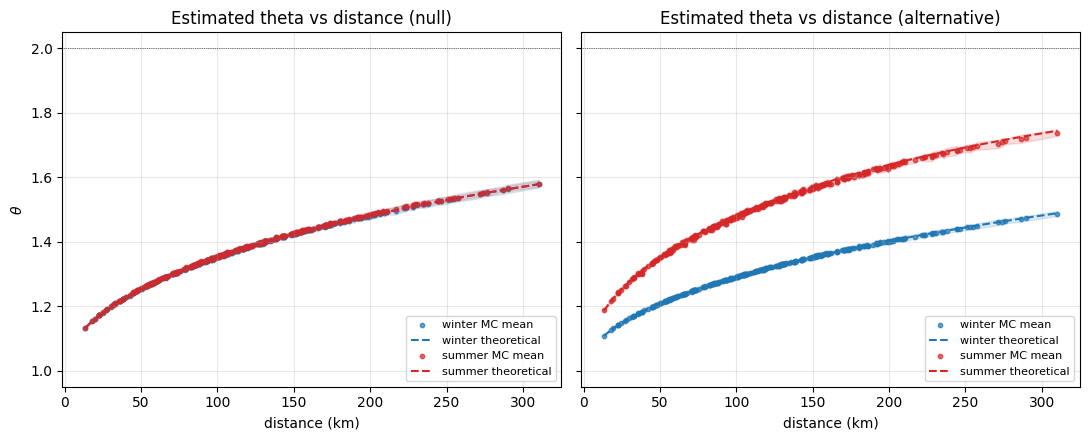

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, scen in zip(axes, ("null", "alternative")):
    sub = raw[raw["scenario"] == scen]
    for season, c in (("winter", "tab:blue"), ("summer", "tab:red")):
        s = sub[sub["season"] == season]
        g = s.groupby(["i", "j", "dist_km"])
        mean_hat = g["theta_hat"].mean()
        sd_hat = g["theta_hat"].std()
        d = mean_hat.index.get_level_values("dist_km").to_numpy()
        o = np.argsort(d)
        ax.scatter(d[o], mean_hat.values[o], s=10, color=c, alpha=0.7, label=f"{season} MC mean")
        ax.fill_between(d[o], (mean_hat - sd_hat).values[o], (mean_hat + sd_hat).values[o], color=c, alpha=0.15)
        true_curve = br_theta(d[o], s["rho_true"].iloc[0], ALPHA)
        ax.plot(d[o], true_curve, color=c, lw=1.5, ls="--", label=f"{season} theoretical")
    ax.set_title(f"Estimated theta vs distance ({scen})")
    ax.set_xlabel("distance (km)")
    ax.set_ylim(0.95, 2.05)
    ax.axhline(2.0, color="k", lw=0.5, ls=":")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel(r"$\theta$")
fig.tight_layout()
plt.show()

## 10. Winter - summer $\theta$ difference

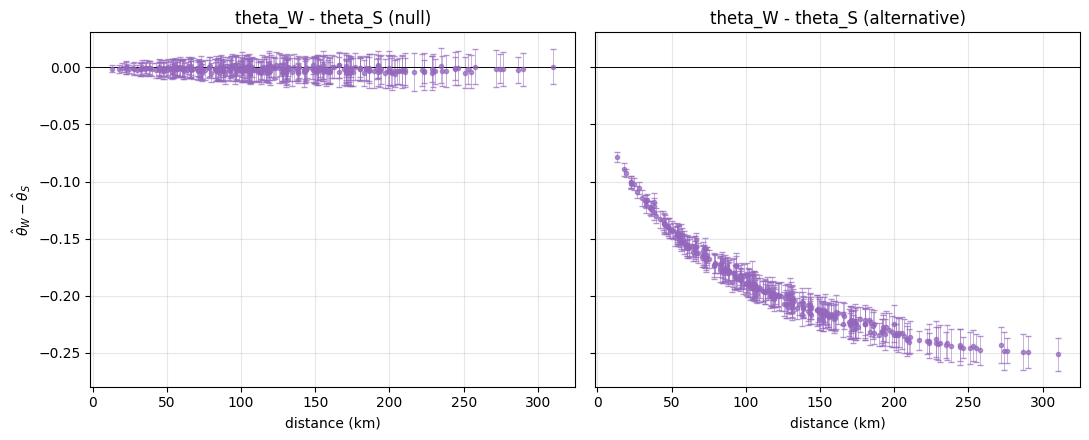

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, scen in zip(axes, ("null", "alternative")):
    sub = wide[wide["scenario"] == scen]
    g = sub.groupby(["i", "j", "dist_km"])
    m = g["theta_hat_diff_W_minus_S"].mean()
    s_ = g["theta_hat_diff_W_minus_S"].std()
    d = m.index.get_level_values("dist_km").to_numpy()
    o = np.argsort(d)
    ax.errorbar(
        d[o], m.values[o], yerr=s_.values[o], fmt="o", ms=3, color="tab:purple", elinewidth=0.5, capsize=2, alpha=0.7
    )
    ax.axhline(0.0, color="k", lw=0.7)
    ax.set_title(f"theta_W - theta_S ({scen})")
    ax.set_xlabel("distance (km)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r"$\hat\theta_W - \hat\theta_S$")
fig.tight_layout()
plt.show()

## 11. Detection rates by distance bin

Probability that the estimator recovers the correct sign of the winter-summer
difference. Under the alternative we expect close to 1; under the null,
approximately 0.5.

In [12]:
wide["dist_bin"] = pd.cut(wide["dist_km"], DIST_BIN_EDGES, include_lowest=True)
wide["correct_theta"] = (wide["theta_hat_diff_W_minus_S"] < 0).astype(int)
for c in [c for c in wide.columns if c.startswith("chi_u_") and c.endswith("_diff_W_minus_S")]:
    u_tag = c.replace("chi_u_", "").replace("_diff_W_minus_S", "")
    wide[f"correct_chi_{u_tag}"] = (wide[c] > 0).astype(int)

detect_cols = [c for c in wide.columns if c.startswith("correct_")]
detection = wide.groupby(["scenario", "dist_bin"], observed=True)[detect_cols].mean().reset_index()
detection

,scenario,dist_bin,correct_theta,correct_chi_0.90,correct_chi_0.95,correct_chi_0.98
0,alternative,"(-0.001, 50.0]",1.000000,1.000000,1.000000,0.991935
1,alternative,"(50.0, 100.0]",1.000000,1.000000,1.000000,1.000000
2,alternative,"(100.0, 150.0]",1.000000,1.000000,1.000000,1.000000
3,alternative,"(150.0, 200.0]",1.000000,1.000000,1.000000,1.000000
4,alternative,"(200.0, 10000.0]",1.000000,1.000000,1.000000,1.000000
5,null,"(-0.001, 50.0]",0.569355,0.532258,0.496774,0.491935
6,null,"(50.0, 100.0]",0.548824,0.538824,0.493529,0.529412
7,null,"(100.0, 150.0]",0.573864,0.535227,0.498295,0.511932
8,null,"(150.0, 200.0]",0.587097,0.522581,0.516935,0.511290
9,null,"(200.0, 10000.0]",0.591176,0.511765,0.497059,0.504412


## 12. Distance-bin summary of $\theta$

In [13]:
raw["dist_bin"] = pd.cut(raw["dist_km"], DIST_BIN_EDGES, include_lowest=True)
binned = (
    raw.groupby(["scenario", "season", "dist_bin"], observed=True)
    .agg(
        theta_hat_mean=("theta_hat", "mean"),
        theta_hat_std=("theta_hat", "std"),
        theta_true_mean=("theta_true", "mean"),
        n=("theta_hat", "count"),
    )
    .reset_index()
)
binned

,scenario,season,dist_bin,theta_hat_mean,theta_hat_std,theta_true_mean,n
0,alternative,summer,"(-0.001, 50.0]",1.292028,0.042824,1.293352,620
1,alternative,summer,"(50.0, 100.0]",1.418255,0.037729,1.420807,1700
2,alternative,summer,"(100.0, 150.0]",1.519597,0.027803,1.523084,1760
3,alternative,summer,"(150.0, 200.0]",1.597194,0.022399,1.601643,1240
4,alternative,summer,"(200.0, 10000.0]",1.672921,0.029486,1.677138,680
5,alternative,winter,"(-0.001, 50.0]",1.172412,0.026010,1.172200,620
6,alternative,winter,"(50.0, 100.0]",1.251726,0.024539,1.251411,1700
7,alternative,winter,"(100.0, 150.0]",1.319113,0.019180,1.318859,1760
8,alternative,winter,"(150.0, 200.0]",1.374635,0.016051,1.374324,1240
9,alternative,winter,"(200.0, 10000.0]",1.431470,0.023569,1.432279,680


## 13. (Optional) save notebook outputs

Mirrors the script's table outputs so the notebook can stand on its own.

In [14]:
SAVE = False  # flip to True to overwrite the script outputs
if SAVE:
    raw.to_csv(config.TABLES_DIR / "sim_pairwise_results.csv", index=False)
    bias.to_csv(config.TABLES_DIR / "sim_bias_rmse_theta.csv", index=False)
    detection.to_csv(config.TABLES_DIR / "sim_detection_summary.csv", index=False)
    binned.to_csv(config.TABLES_DIR / "sim_distance_bin_summary.csv", index=False)
    print("saved")
else:
    print("SAVE=False, nothing written")

SAVE=False, nothing written


## Interpretation

**Methodological question:** can the proposed pairwise estimators recover the
true spatial extremal-dependence dynamics given a finite sample size similar to
the empirical KNMI daily-maxima panel?

- **Alternative regime**: when winter is generated with $\rho_W = 180$ km and
  summer with $\rho_S = 60$ km, the F-madogram-based $\theta$ recovers
  $\theta_W(h) < \theta_S(h)$ at every distance bin. Bias of $\theta$ is small
  ($\lesssim 10^{-2}$), RMSE is of order $10^{-2}$, and the detection rate of
  the correct sign is essentially 1 over $\binom{25}{2} = 300$ pairs.
- **Null regime**: when winter and summer share the same variogram, the
  estimator produces no systematic seasonal difference (detection rate is
  close to 0.5).
- $\chi_u$ at $u = 0.90, 0.95$ behaves analogously; at $u = 0.98$ the
  exceedance count is small and variability widens.

These results support using the F-madogram, $\theta$, and $\chi_u$ estimators
in the empirical analysis of winter vs summer spatial extremal dependence.